In [40]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import jn_zeros, jv

In [ ]:
nmax = 3
mmax = 4
knm = np.zeros((nmax+1, mmax+1))

for n in range(nmax+1):
    knm[n, 1:mmax+1] = jn_zeros(n, mmax)

In [ ]:
def phi(n: int, m: int, r: np.ndarray, theta: np.ndarray) -> np.ndarray:
    return jv(n, knm[n, m]*r)*np.cos(n*theta)

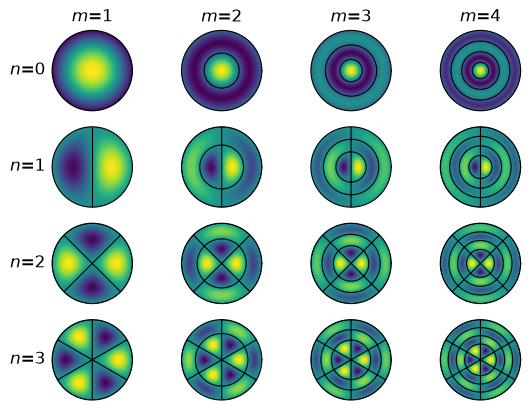

In [57]:
fig, ax = plt.subplots(mmax, mmax, subplot_kw={'projection': 'polar'})

r = np.linspace(0.0, 1.0, 100)
theta = np.linspace(0.0, 2*np.pi, 100)
R, Theta = np.meshgrid(r, theta)

for n in range(nmax+1):
    for m in range(1, mmax+1):
        Z = phi(n, m, R, Theta)
        axis = ax[n, m-1]
        axis.contourf(Theta, R, Z, levels=50)
        axis.set_xticklabels([])
        axis.set_yticklabels([])
        axis.grid(False)
        axis.contour(Theta, R, Z, levels=[0], colors='k', linewidths=0.8)

        if m == 1:
            axis.annotate(fr'$n$={n}', xy=(-0.3, 0.5), xycoords='axes fraction',
                          ha='center', va='center', fontsize=12)
        if n == 0:
            axis.set_title(fr'$m$={m}', fontsize=12)

In [58]:
fig.tight_layout()
fig.savefig('drumhead-modes.png', dpi=300)